# Another day another dollar

In [ ]:
# 1. Load and Parse the Dataset
data = pd.read_csv('/mnt/data/england-premier-league-matches-2018-to-2019-stats.csv')

# Extract date and match details from the `timestamp` column
data[['timestamp', 'date', 'time', 'details']] = data['timestamp'].str.extract(
    r'(?P<timestamp>\d+),(?P<date>[^,]+) - (?P<time>[^\s]+),(?P<details>.+)')

# Convert numeric target columns to float (goal counts)
data['home_team_goal_count'] = pd.to_numeric(data['home_team_goal_count'], errors='coerce')
data['away_team_goal_count'] = pd.to_numeric(data['away_team_goal_count'], errors='coerce')

# 2. Feature Selection: Retain Relevant Features
features = ['home_team_shots', 'away_team_shots', 
            'home_team_possession', 'away_team_possession', 
            'home_team_goal_count', 'away_team_goal_count']
data = data[features]

# Drop rows with missing target data
data.dropna(subset=['home_team_goal_count', 'away_team_goal_count'], inplace=True)

# Fill missing values in features with column means
data.fillna(data.mean(), inplace=True)

# 3. Define Features (X) and Targets (y)
X = data.drop(columns=['home_team_goal_count', 'away_team_goal_count'])
y = data[['home_team_goal_count', 'away_team_goal_count']]

# 4. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predictions and Evaluation
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred)}")
print(f"R^2 Score: {r2_score(y_test, y_pred)}")

# 7. Results Summary
results = pd.DataFrame({
    'Actual_HomeScore': y_test['home_team_goal_count'].values,
    'Predicted_HomeScore': y_pred[:, 0],
    'Actual_AwayScore': y_test['away_team_goal_count'].values,
    'Predicted_AwayScore': y_pred[:, 1]
})
print(results.head())


# Key Features to Prioritize for Football Score Prediction

## Match-Specific Performance Metrics
These are immediate indicators of a team's performance in the game:
- **Shots**:
  - `home_team_shots`, `away_team_shots`: Total attempts to score.
  - `home_team_shots_on_target`, `away_team_shots_on_target`: Accuracy of shots matters.
  - `home_team_shots_off_target`, `away_team_shots_off_target`: Wasted opportunities.
- **Possession**:
  - `home_team_possession`, `away_team_possession`: Indicates which team dominated the game.
- **Corners**:
  - `home_team_corner_count`, `away_team_corner_count`: Proxy for attacking intensity.

## Pre-Match Statistics
These capture form and historical performance:
- **Pre-Match Goals Scored/Conceded**:
  - Average goals scored/conceded over the last 5 matches.
- **Pre-Match Points per Game (PPG)**:
  - `home_ppg`, `away_ppg`: Indicates overall team quality.
- **Expected Goals (xG)**:
  - `Home Team Pre-Match xG`, `Away Team Pre-Match xG`: Statistical probability of goals based on shots and quality of attempts.

## Team Discipline and Fouls
- **Cards**:
  - `home_team_yellow_cards`, `away_team_yellow_cards`: High card counts may indicate defensive struggles.
  - `home_team_red_cards`, `away_team_red_cards`: Impact player availability mid-game.
- **Fouls**:
  - `home_team_fouls`, `away_team_fouls`: Impacts match control and possession.

## Dynamic Features
- **Recent Form**:
  - Goal difference and points from last 5 matches for both teams.
  - Head-to-head results (historical outcomes between the two teams).
- **Streaks**:
  - Winning, drawing, or losing streaks leading up to the match.

## Contextual Features
- **Home Advantage**:
  - Historical performance of the home team at their stadium.
- **Stadium Factors**:
  - `stadium_name`: Some venues may favor specific playing styles.
- **Weather Conditions** (if available):
  - Heavy rain or wind may affect scoring dynamics.

---

# Rationale for Prioritization

## Performance Metrics
These features directly impact scorelines, as they represent offensive and defensive efficiency during matches.

## Pre-Match Statistics
Pre-match xG and PPG help capture team form and quality, which are strong predictors of outcomes.

## Discipline and Fouls
Cards and fouls can indicate disruptions in gameplay or missing key players, which influence goal-scoring opportunities.

## Dynamic and Contextual Factors
Recent form and head-to-head results provide insights into how the teams are likely to perform based on historical and current trends.

---

# Feature Selection Techniques

## 1. Correlation Analysis
Assess how each feature correlates with the target scores (e.g., `home_team_goal_count` and `away_team_goal_count`).

## 2. Feature Importance with Tree-Based Models
Use Random Forest or Gradient Boosting to rank features based on their contribution to predictions.

## 3. Recursive Feature Elimination (RFE)
Iteratively remove the least important features and evaluate model performance.

## 4. Domain Knowledge
Use football expertise to supplement statistical methods, ensuring relevant features are prioritized.

---

Would you like a Python implementation to prioritize these features or insights into incorporating specific feature engineering strategies?


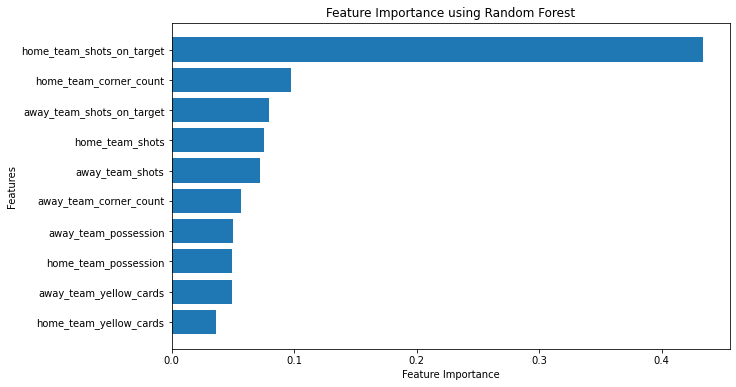

Selected Features using RFE: Index(['home_team_shots', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'away_team_possession',
       'home_team_corner_count'],
      dtype='object')
Mean Absolute Error (MAE): 0.9548684210526317
Mean Squared Error (MSE): 1.3703907894736842
R^2 Score: 0.12129471580817042


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('../data/england-premier-league-matches-2018-to-2019-stats.csv')

# Select relevant columns (example: shots, possession, goals, cards, etc.)
columns_to_keep = [
    'home_team_shots', 'away_team_shots', 
    'home_team_shots_on_target', 'away_team_shots_on_target',
    'home_team_possession', 'away_team_possession',
    'home_team_corner_count', 'away_team_corner_count',
    'home_team_yellow_cards', 'away_team_yellow_cards',
    'home_team_goal_count', 'away_team_goal_count'
]

# Retain only the required columns
data = data[columns_to_keep]

# Handle missing values
data.dropna(subset=['home_team_goal_count', 'away_team_goal_count'], inplace=True)
data.fillna(data.mean(), inplace=True)

# Define features (X) and targets (y)
X = data.drop(columns=['home_team_goal_count', 'away_team_goal_count'])
y = data[['home_team_goal_count', 'away_team_goal_count']]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor for feature importance
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train['home_team_goal_count'])  # Fitting only for home_team_goal_count for demonstration

# Feature importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance using Random Forest')
plt.gca().invert_yaxis()
plt.show()

# Recursive Feature Elimination (RFE)
rfe_model = RFE(estimator=rf, n_features_to_select=5)
rfe_model.fit(X_train, y_train['home_team_goal_count'])  # Fitting only for home_team_goal_count

# Selected features
selected_features = X.columns[rfe_model.support_]
print("Selected Features using RFE:", selected_features)

# Evaluate the model on test data
y_pred = rf.predict(X_test)

# Metrics
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test['home_team_goal_count'], y_pred)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test['home_team_goal_count'], y_pred)}")
print(f"R^2 Score: {r2_score(y_test['home_team_goal_count'], y_pred)}")


Here’s the rewritten code to compare the importance of every feature in predicting both home_team_goal_count and away_team_goal_count. This version evaluates feature importance separately for the two targets and provides insights into their relative contributions:

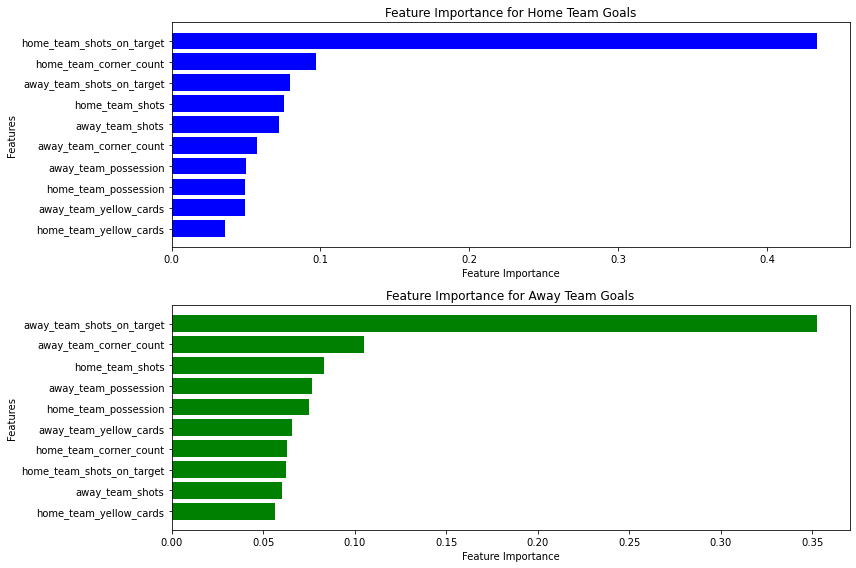

Selected Features for Home Team Goals using RFE: Index(['home_team_shots', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'away_team_possession',
       'home_team_corner_count'],
      dtype='object')
Selected Features for Away Team Goals using RFE: Index(['home_team_shots', 'away_team_shots_on_target', 'home_team_possession',
       'away_team_possession', 'away_team_corner_count'],
      dtype='object')

--- Home Team Goals ---
Mean Absolute Error (MAE): 0.9548684210526317
Mean Squared Error (MSE): 1.3703907894736842
R^2 Score: 0.12129471580817042

--- Away Team Goals ---
Mean Absolute Error (MAE): 0.7089473684210525
Mean Squared Error (MSE): 0.8511368421052631
R^2 Score: 0.17734832663989286


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('../data/england-premier-league-matches-2018-to-2019-stats.csv')

# Select relevant columns
columns_to_keep = [
    'home_team_shots', 'away_team_shots', 
    'home_team_shots_on_target', 'away_team_shots_on_target',
    'home_team_possession', 'away_team_possession',
    'home_team_corner_count', 'away_team_corner_count',
    'home_team_yellow_cards', 'away_team_yellow_cards',
    'home_team_goal_count', 'away_team_goal_count'
]

# Retain only the required columns
data = data[columns_to_keep]

# Handle missing values
data.dropna(subset=['home_team_goal_count', 'away_team_goal_count'], inplace=True)
data.fillna(data.mean(), inplace=True)

# Define features (X) and targets (y)
X = data.drop(columns=['home_team_goal_count', 'away_team_goal_count'])
y_home = data['home_team_goal_count']
y_away = data['away_team_goal_count']

# Train-Test Split for Home Team Goals
X_train_home, X_test_home, y_train_home, y_test_home = train_test_split(X, y_home, test_size=0.2, random_state=42)

# Train-Test Split for Away Team Goals
X_train_away, X_test_away, y_train_away, y_test_away = train_test_split(X, y_away, test_size=0.2, random_state=42)

# Train Random Forest Regressor for Home Team Goals
rf_home = RandomForestRegressor(random_state=42)
rf_home.fit(X_train_home, y_train_home)

# Train Random Forest Regressor for Away Team Goals
rf_away = RandomForestRegressor(random_state=42)
rf_away.fit(X_train_away, y_train_away)

# Feature importance for Home Team Goals
importances_home = rf_home.feature_importances_
feature_importance_home_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_home})
feature_importance_home_df.sort_values(by='Importance', ascending=False, inplace=True)

# Feature importance for Away Team Goals
importances_away = rf_away.feature_importances_
feature_importance_away_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_away})
feature_importance_away_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importance for Home and Away Team Goals
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(feature_importance_home_df['Feature'], feature_importance_home_df['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Home Team Goals')
plt.gca().invert_yaxis()

plt.subplot(2, 1, 2)
plt.barh(feature_importance_away_df['Feature'], feature_importance_away_df['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Away Team Goals')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Recursive Feature Elimination (RFE) for Home Team Goals
rfe_model_home = RFE(estimator=rf_home, n_features_to_select=5)
rfe_model_home.fit(X_train_home, y_train_home)
selected_features_home = X.columns[rfe_model_home.support_]

# Recursive Feature Elimination (RFE) for Away Team Goals
rfe_model_away = RFE(estimator=rf_away, n_features_to_select=5)
rfe_model_away.fit(X_train_away, y_train_away)
selected_features_away = X.columns[rfe_model_away.support_]

# Print selected features
print("Selected Features for Home Team Goals using RFE:", selected_features_home)
print("Selected Features for Away Team Goals using RFE:", selected_features_away)

# Evaluate both models on test data
y_pred_home = rf_home.predict(X_test_home)
y_pred_away = rf_away.predict(X_test_away)

# Metrics for Home Team Goals
print("\n--- Home Team Goals ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home)}")

# Metrics for Away Team Goals
print("\n--- Away Team Goals ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away)}")


Key Changes
Separate Models for Home and Away Scores:

Trained separate RandomForestRegressor models for home_team_goal_count and away_team_goal_count.
Computed and visualized feature importance for both targets.
Feature Importance Visualization:

Created separate bar plots for features affecting home and away scores.
Allows comparison of how different features contribute to each target.
Recursive Feature Elimination (RFE):

Identified the top 5 features for predicting home and away goals separately.
Metrics for Both Targets:

Evaluated model performance using MAE, MSE, and R² scores for home and away scores independently.
Interpretation
Compare the features selected by RFE and those with high importance from the Random Forest models.
Investigate differences in feature importance between home and away scores to refine feature engineering.
Let me know if you’d like further refinements or deeper analysis of these results!